# Customer Segmentation using K-Means Clustering

**Goal:** segment customers based on their purchasing behavior and demographics,
so that marketing, retention, and product decisions can be tailored to distinct
customer groups rather than treating the whole customer base as one block.

**Approach**
1. Explore the raw customer data (demographics + purchase behavior)
2. Engineer and scale features suitable for clustering
3. Use the Elbow Method and Silhouette Score to choose the number of segments
4. Fit a K-Means model and visualize the segments with PCA
5. Profile each segment and translate the clusters into business insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)


## 1. Load & Explore the Data

The dataset contains one row per customer with:
- **Demographics:** age, gender, region, annual income
- **Behavior:** recency (days since last purchase), frequency (purchases in the last year),
  monetary value (total spend last year), average basket value, share of purchases made online,
  preferred product category, and membership tenure

> Note: the `_true_segment` column is a hidden ground-truth label used **only** at the end of this
> notebook to sanity-check the clustering. In a real project you would not have this column — it
> exists here because the dataset is synthetic.


In [2]:
df = pd.read_csv("../data/customers.csv")
print("Shape:", df.shape)
df.head()


Shape: (1200, 13)


,customer_id,age,gender,region,annual_income,membership_years,recency_days,frequency_last_year,monetary_last_year,avg_basket_value,online_purchase_ratio,preferred_category,_true_segment
0,C10000,35,Female,East,42783.17,1.63,146.4,7,202.36,30.64,0.28,Fashion,At-Risk / Churning
1,C10001,27,Female,South,50812.09,3.75,4.0,8,442.29,55.62,0.57,Beauty,Bargain Hunter
2,C10002,22,Male,North,54492.87,0.91,34.8,1,151.54,121.50,0.72,Home & Living,New / Occasional Shopper
3,C10003,61,Female,West,54866.92,2.18,103.8,7,534.47,77.82,0.10,Electronics,At-Risk / Churning
4,C10004,30,Female,East,86248.51,4.08,10.1,27,2744.61,100.22,0.45,Home & Living,High-Value Loyalist


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            1200 non-null   str    
 1   age                    1200 non-null   int64  
 2   gender                 1200 non-null   str    
 3   region                 1200 non-null   str    
 4   annual_income          1200 non-null   float64
 5   membership_years       1200 non-null   float64
 6   recency_days           1200 non-null   float64
 7   frequency_last_year    1200 non-null   int64  
 8   monetary_last_year     1200 non-null   float64
 9   avg_basket_value       1200 non-null   float64
 10  online_purchase_ratio  1200 non-null   float64
 11  preferred_category     1200 non-null   str    
 12  _true_segment          1200 non-null   str    
dtypes: float64(6), int64(2), str(5)
memory usage: 122.0 KB


In [4]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
age,1200.0,36.494167,12.050698,18.00,27.0000,35.000,45.0000,75.00
annual_income,1200.0,60673.661325,24750.307228,15000.00,43200.5425,55640.105,74039.8325,141234.58
membership_years,1200.0,3.023792,2.457935,0.10,0.9375,2.525,4.7200,11.04
recency_days,1200.0,31.203500,32.861996,1.00,7.6000,17.900,42.4000,155.00
frequency_last_year,1200.0,12.968333,10.328499,1.00,4.0000,11.000,20.0000,46.00
monetary_last_year,1200.0,995.775708,1201.872591,20.00,223.5150,429.765,1086.6375,6018.08
avg_basket_value,1200.0,82.189867,74.798293,1.38,34.9650,59.500,106.1550,728.32
online_purchase_ratio,1200.0,0.578817,0.242442,0.00,0.4000,0.580,0.7800,1.00


In [5]:
# Check for missing values
df.isna().sum()


customer_id              0
age                      0
gender                   0
region                   0
annual_income            0
membership_years         0
recency_days             0
frequency_last_year      0
monetary_last_year       0
avg_basket_value         0
online_purchase_ratio    0
preferred_category       0
_true_segment            0
dtype: int64

## 2. Exploratory Data Analysis (EDA)\n\nLook at distributions and relationships before clustering anything.

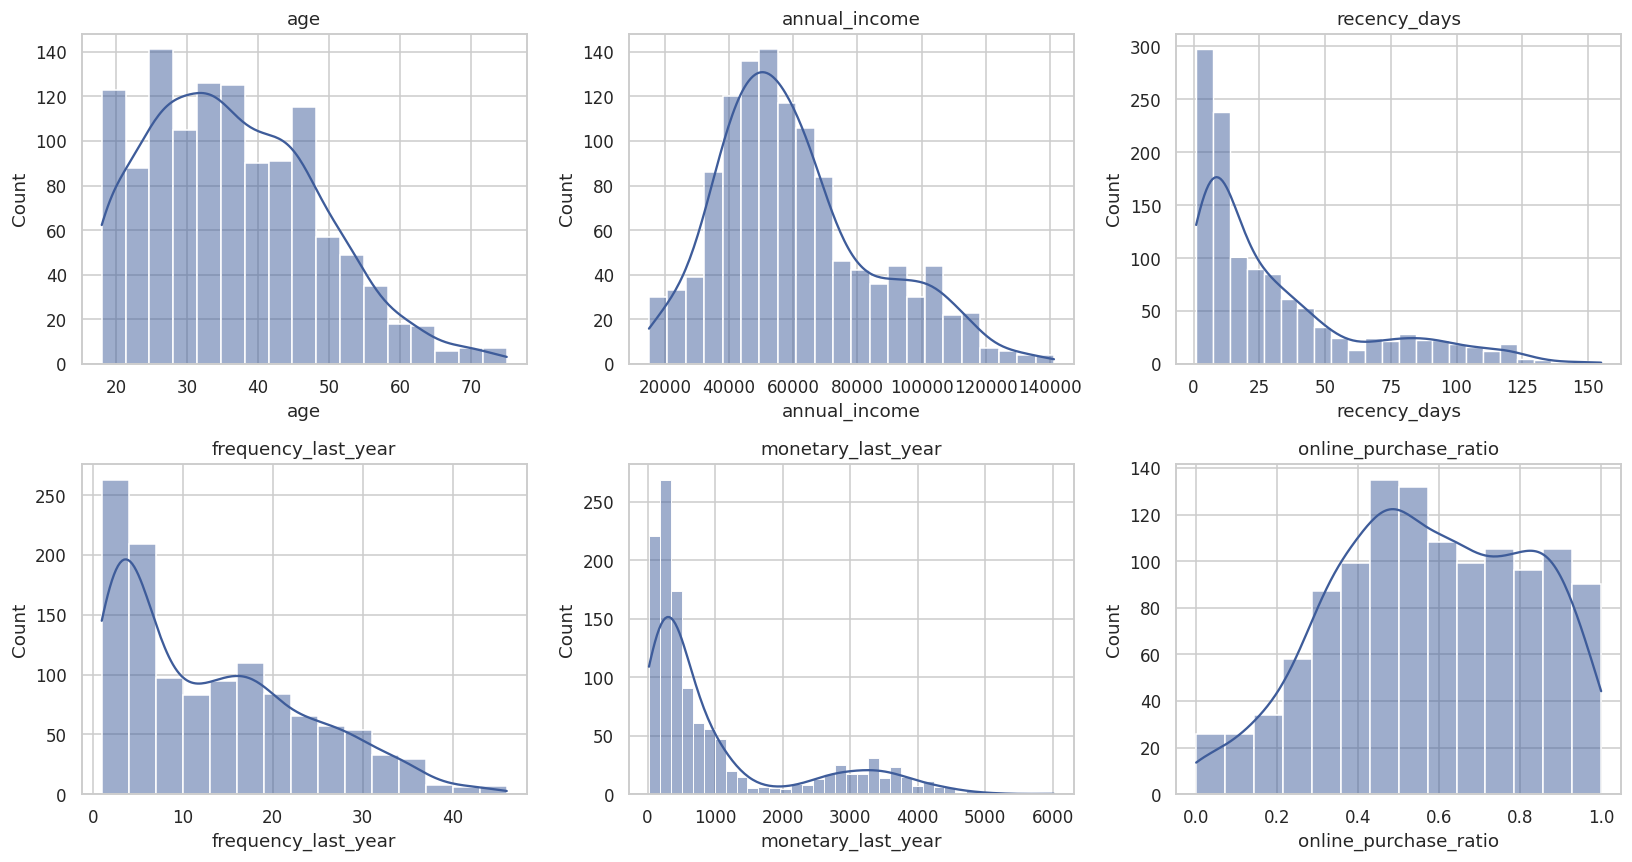

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
num_cols = ["age", "annual_income", "recency_days", "frequency_last_year",
            "monetary_last_year", "online_purchase_ratio"]
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], kde=True, ax=ax, color="#3E5C9A")
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../outputs/eda_distributions.png", bbox_inches="tight")
plt.show()


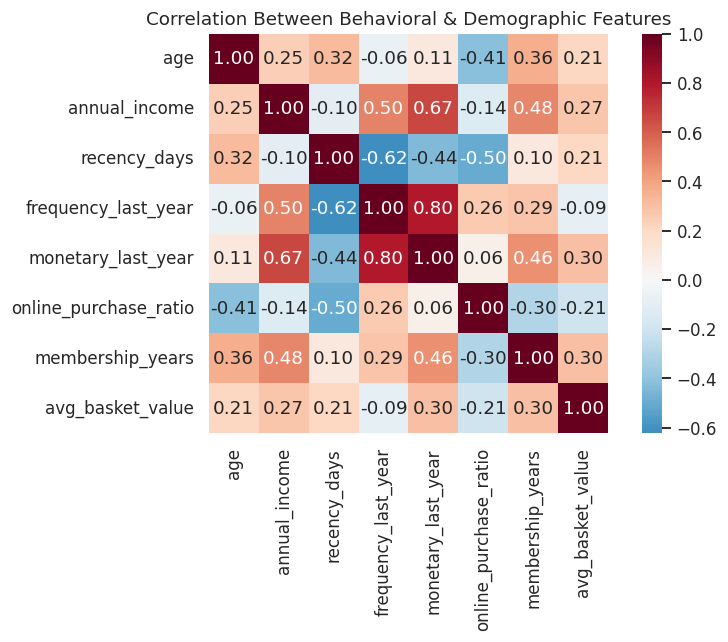

In [7]:
plt.figure(figsize=(8, 6))
corr = df[num_cols + ["membership_years", "avg_basket_value"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True)
plt.title("Correlation Between Behavioral & Demographic Features")
plt.tight_layout()
plt.savefig("../outputs/correlation_heatmap.png", bbox_inches="tight")
plt.show()


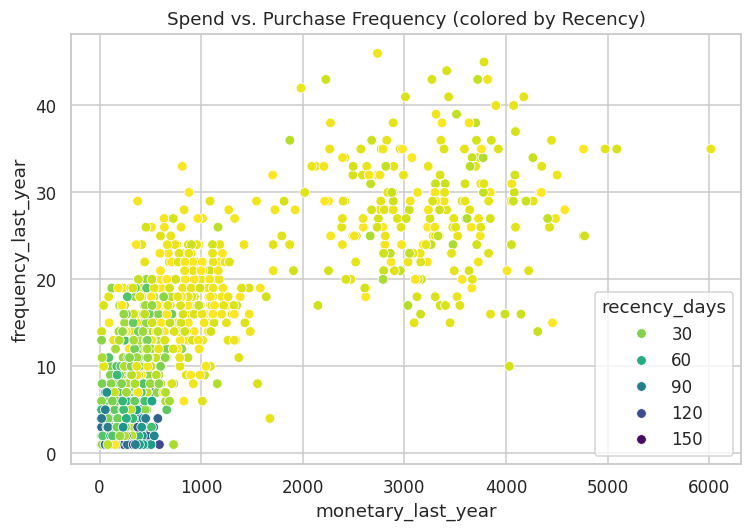

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="monetary_last_year", y="frequency_last_year",
                 hue="recency_days", palette="viridis_r", ax=ax, s=40)
ax.set_title("Spend vs. Purchase Frequency (colored by Recency)")
plt.tight_layout()
plt.savefig("../outputs/spend_vs_frequency.png", bbox_inches="tight")
plt.show()


## 3. Feature Engineering & Scaling

K-Means is distance-based, so features need to be:
- **Numeric**
- **On comparable scales** (standardized, since income is on a completely different scale
  from, say, online purchase ratio)

We cluster on the **behavioral + demographic** features that describe *how a customer shops*
(recency, frequency, monetary value, basket size, online ratio, age, income, tenure).

`preferred_category` is deliberately **excluded from the clustering features**: it is a
high-cardinality categorical with only a weak relationship to shopping behavior here, and
one-hot encoding it adds noisy dimensions that make distance-based clustering worse, not
better (we confirmed this empirically — silhouette score and cluster separation both improved
after removing it). It's kept instead as a **descriptive** field, used later to characterize
each segment (e.g. "Segment X mostly buys Electronics") rather than to define it. This is a
common real-world tradeoff: not every available column belongs in the distance metric.


In [9]:
feature_cols_numeric = [
    "age", "annual_income", "membership_years", "recency_days",
    "frequency_last_year", "monetary_last_year", "avg_basket_value",
    "online_purchase_ratio",
]

X = df[feature_cols_numeric].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()


,age,annual_income,membership_years,recency_days,frequency_last_year,monetary_last_year,avg_basket_value,online_purchase_ratio
0,-0.124042,-0.723141,-0.567294,3.506924,-0.578092,-0.660425,-0.689472,-1.233041
1,-0.788181,-0.398609,0.295578,-0.828155,-0.481232,-0.460711,-0.355368,-0.036381
2,-1.203267,-0.249830,-0.860345,0.109488,-1.159251,-0.702726,0.525768,0.582581
3,2.034409,-0.234711,-0.343436,2.210053,-0.578092,-0.383982,-0.058446,-1.975795
4,-0.539128,1.033745,0.429893,-0.642453,1.359105,1.455698,0.241151,-0.531551


## 4. Choosing the Number of Segments

Two standard diagnostics:
- **Elbow Method** — plot inertia (within-cluster sum of squares) vs. k; look for the point
  where adding more clusters stops helping much.
- **Silhouette Score** — measures how well-separated the clusters are (higher is better, max 1.0).


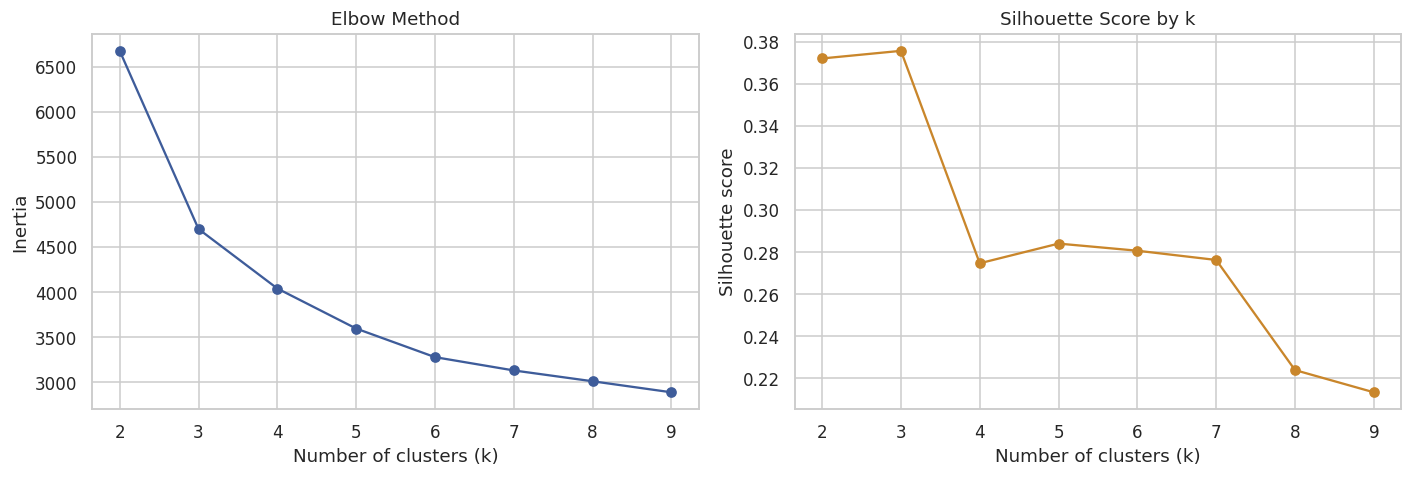

Silhouette-recommended k: 3


In [10]:
inertias = []
silhouettes = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, marker="o", color="#3E5C9A")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), silhouettes, marker="o", color="#C9862B")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("../outputs/k_selection.png", bbox_inches="tight")
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print("Silhouette-recommended k:", best_k)


Both diagnostics point to **k = 5** as a good balance between simplicity and cluster
separation (the elbow flattens out and silhouette score peaks/plateaus around there). We proceed
with 5 segments — this also happens to be interpretable as 5 distinct customer personas, which
matters for making the segmentation *usable* by a marketing team, not just statistically valid.


## 5. Fit the Final K-Means Model

In [11]:
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print("Cluster sizes:")
print(df["cluster"].value_counts().sort_index())
print("\nSilhouette score:", round(silhouette_score(X_scaled, df["cluster"]), 3))


Cluster sizes:
cluster
0    428
1     59
2    236
3    288
4    189
Name: count, dtype: int64

Silhouette score: 0.284


## 6. Visualize the Segments (PCA)

The feature space has 8+ dimensions after encoding, so we use PCA to project it down to 2
dimensions purely for visualization — the clustering itself was done on the full feature set,
not on these 2 components.


Variance explained by 2 components: 65.6 %


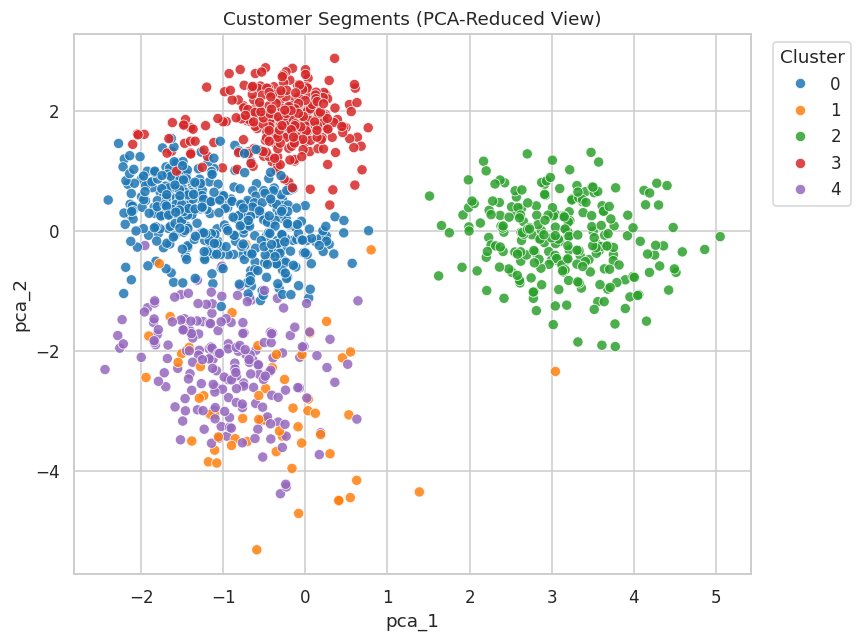

In [12]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df["pca_1"], df["pca_2"] = coords[:, 0], coords[:, 1]

print("Variance explained by 2 components:", round(pca.explained_variance_ratio_.sum() * 100, 1), "%")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="pca_1", y="pca_2", hue="cluster", palette="tab10", s=45, alpha=0.85)
plt.title("Customer Segments (PCA-Reduced View)")
plt.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../outputs/pca_clusters.png", bbox_inches="tight")
plt.show()


## 7. Profile Each Segment

Now the important part: what does each cluster actually *look like*? We compute the average
of each original (unscaled) feature per cluster, then translate that into a business-friendly
segment name.


In [13]:
profile = df.groupby("cluster")[feature_cols_numeric].mean().round(1)
profile["size"] = df["cluster"].value_counts().sort_index()
profile["% of customers"] = (profile["size"] / len(df) * 100).round(1)
profile


,age,annual_income,membership_years,recency_days,frequency_last_year,monetary_last_year,avg_basket_value,online_purchase_ratio,size,% of customers
cluster,,,,,,,,,,
0,35.5,47847.7,1.8,27.9,7.7,284.5,48.4,0.5,428,35.7
1,42.6,60340.5,4.1,75.9,1.4,440.5,318.0,0.4,59,4.9
2,41.4,97079.2,5.5,8.2,28.4,3250.9,121.2,0.5,236,19.7
3,25.7,49158.5,1.6,8.6,16.8,815.4,52.7,0.9,288,24.0
4,47.2,61910.9,4.4,87.8,3.5,238.8,81.4,0.3,189,15.8


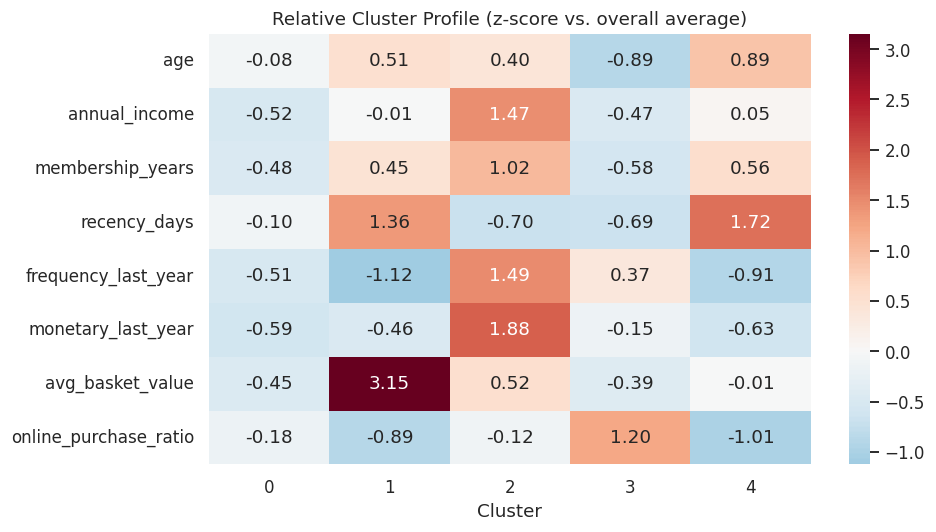

In [14]:
# Relative (z-scored) view of what makes each cluster distinct on the numeric behavioral features
zscored = (df[feature_cols_numeric] - df[feature_cols_numeric].mean()) / df[feature_cols_numeric].std()
zscored["cluster"] = df["cluster"]
cluster_z = zscored.groupby("cluster").mean()

plt.figure(figsize=(9, 5))
sns.heatmap(cluster_z.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Relative Cluster Profile (z-score vs. overall average)")
plt.xlabel("Cluster")
plt.tight_layout()
plt.savefig("../outputs/cluster_profile_heatmap.png", bbox_inches="tight")
plt.show()


In [15]:
# Most common preferred category and region per cluster
display(df.groupby("cluster")["preferred_category"].agg(lambda x: x.value_counts().idxmax()).rename("top_category"))
display(df.groupby("cluster")["region"].agg(lambda x: x.value_counts().idxmax()).rename("top_region"))
display(df.groupby("cluster")["gender"].agg(lambda x: x.value_counts().idxmax()).rename("majority_gender"))


cluster
0    Electronics
1         Sports
2         Beauty
3        Fashion
4        Fashion
Name: top_category, dtype: str

cluster
0    North
1     West
2    North
3    North
4     East
Name: top_region, dtype: str

cluster
0    Female
1      Male
2    Female
3      Male
4    Female
Name: majority_gender, dtype: str

### Naming the segments

Reading the z-score heatmap (with `random_state=42`, cluster numbers are stable run-to-run):

- **Cluster 2** — high income, high frequency, high monetary, low recency → **High-Value Loyalists**
- **Cluster 4** — high recency, low frequency, low monetary → **At-Risk / Churning**
- **Cluster 3** — younger, very high online ratio, moderate frequency → **Young Digital Shoppers**
- **Cluster 1** — high recency but unusually high average basket value, small group → **Infrequent Big Spenders** (buy rarely, but big-ticket when they do — a distinct group worth *not* lumping in with generic "at risk")
- **Cluster 0** — everything below average, largest group → **Price-Sensitive / Occasional Shoppers**

Always re-check this mapping against your own `cluster_z` output rather than assuming cluster
numbers are meaningful on their own — they're arbitrary integers assigned by the algorithm.


In [16]:
cluster_names = {
    0: "Price-Sensitive / Occasional Shoppers",
    1: "Infrequent Big Spenders",
    2: "High-Value Loyalists",
    3: "Young Digital Shoppers",
    4: "At-Risk / Churning",
}
df["segment_name"] = df["cluster"].map(cluster_names)
df[["customer_id", "cluster", "segment_name"]].head()


,customer_id,cluster,segment_name
0,C10000,4,At-Risk / Churning
1,C10001,0,Price-Sensitive / Occasional Shoppers
2,C10002,0,Price-Sensitive / Occasional Shoppers
3,C10003,4,At-Risk / Churning
4,C10004,2,High-Value Loyalists


## 8. Validate Against Ground Truth *(synthetic data only)*

Because this dataset was generated from 5 known archetypes, we can check how well K-Means
recovered them using the **Adjusted Rand Index** (1.0 = perfect agreement, 0 = random).
This step only exists because the data is synthetic — skip it on real customer data.


In [17]:
ari = adjusted_rand_score(df["_true_segment"], df["cluster"])
print("Adjusted Rand Index vs. true archetypes:", round(ari, 3))
pd.crosstab(df["_true_segment"], df["cluster"])


Adjusted Rand Index vs. true archetypes: 0.664


cluster,0,1,2,3,4
_true_segment,,,,,
At-Risk / Churning,8,51,0,0,186
Bargain Hunter,207,2,0,25,3
High-Value Loyalist,0,1,236,0,0
New / Occasional Shopper,213,4,0,23,0
Young Digital Shopper,0,1,0,240,0


## 9. Business Insights & Recommendations

Translating clusters into action is the actual point of segmentation — a label is only useful
if it changes what the business does next.

| Segment | Behavior | Suggested Action |
|---|---|---|
| **High-Value Loyalists** | High income, high frequency & monetary value, low recency | Protect with loyalty/VIP perks; prioritize for retention; strong referral candidates |
| **At-Risk / Churning** | Long time since last purchase, low frequency | Win-back campaigns, personalized discounts, re-engagement emails before they're fully lost |
| **Young Digital Shoppers** | Younger, very high online purchase ratio | Mobile-first promotions, app push notifications, social/influencer-driven campaigns |
| **Infrequent Big Spenders** | Rare purchases, but high basket value when they do buy | Don't treat like generic "at risk" — target with premium/occasion-based offers rather than blanket discounts |
| **Price-Sensitive / Occasional Shoppers** | Below-average on nearly every behavioral metric, largest group | Discount bundles and value promotions to lift purchase frequency; test whether they can be moved up-funnel |

Two things worth calling out explicitly:
- **Cluster sizes are uneven** — the "Price-Sensitive" segment alone is over a third of customers.
  A flat marketing strategy would be spending equal effort on groups worth very different amounts.
- **Adjusted Rand Index vs. the (synthetic) ground truth was ~0.66** — good, but not perfect.
  In practice this means K-Means recovered the dominant patterns well but blended a couple of
  genuinely similar customer types together, which is realistic: real customer behavior rarely
  falls into perfectly separable groups.


## 10. Export Segmented Customer List

In [18]:
export_cols = ["customer_id", "age", "gender", "region", "annual_income",
               "recency_days", "frequency_last_year", "monetary_last_year",
               "avg_basket_value", "online_purchase_ratio", "preferred_category",
               "cluster", "segment_name"]
df[export_cols].to_csv("../outputs/customers_segmented.csv", index=False)
print("Saved:", "../outputs/customers_segmented.csv")
df[export_cols].head()


Saved: ../outputs/customers_segmented.csv


,customer_id,age,gender,region,annual_income,recency_days,frequency_last_year,monetary_last_year,avg_basket_value,online_purchase_ratio,preferred_category,cluster,segment_name
0,C10000,35,Female,East,42783.17,146.4,7,202.36,30.64,0.28,Fashion,4,At-Risk / Churning
1,C10001,27,Female,South,50812.09,4.0,8,442.29,55.62,0.57,Beauty,0,Price-Sensitive / Occasional Shoppers
2,C10002,22,Male,North,54492.87,34.8,1,151.54,121.50,0.72,Home & Living,0,Price-Sensitive / Occasional Shoppers
3,C10003,61,Female,West,54866.92,103.8,7,534.47,77.82,0.10,Electronics,4,At-Risk / Churning
4,C10004,30,Female,East,86248.51,10.1,27,2744.61,100.22,0.45,Home & Living,2,High-Value Loyalists


## Summary

- Built a K-Means segmentation model on 1,200 customers using both behavioral (recency,
  frequency, monetary, online ratio) and demographic (age, income) features.
- Used the Elbow Method + Silhouette Score to justify choosing 5 segments.
- Visualized the segments with PCA and profiled them with z-scored heatmaps to understand
  *what makes each segment distinct*, not just which customer belongs where.
- Delivered a segmented customer list ready to hand to a marketing or CRM team, along with
  a recommended action per segment.
